# LOOK — Deep Learning Project using MLOps

**Group Members:**
- Hamdha — COHNDDS25.1F-013
- Hemara — COHNDDS25.1F-012
- Lakshika — COHNDDS25.1F-014

#### **GitHub:** https://github.com/Hamdha-Saheer/look-eyewear-recommendation
---

## Section 1 — Problem Definition

### 1.1 Problem
People waste time and money buying eyewear that does not suit their face shape. LOOK uses a CNN to detect face shape from a single photo, recommends suitable glasses styles, and provides virtual try-on AR.

### 1.2 Assumptions
- Input photos are front-facing with good lighting
- Subjects are not wearing glasses or face coverings
- Face shape follows 5 categories: oval, round, square, heart, oblong

### 1.3 Limitations
- Male model 41.0% accuracy — only 128 images per class
- Female model 71.0% accuracy — 623 images per class
- Face shape is subjective — human experts disagree about 25% of the time
- Not trained on side-profile or occluded faces

### 1.4 Dataset Description
-The dataset was curated by collecting images from Google Images using face shape search queries, combined with annotated face-shape benchmark datasets sourced from Roboflow.
- 98 bad images removed using MediaPipe face detection scan
- Male: 128 per class x 5 shapes = 640 train | 193 test
- Female: 623 per class x 5 shapes = 3115 train | 935 test

In [1]:
import os

print('Dataset Summary:')
for gender in ['male', 'female']:
    for split in ['train', 'valid', 'test']:
        path = f'data_clean/{gender}/{split}'
        if not os.path.exists(path):
            continue
        total = 0
        for shape in os.listdir(path):
            sp = os.path.join(path, shape)
            if os.path.isdir(sp):
                total += len(os.listdir(sp))
        print(f'  {gender:6s} {split:5s}: {total} images')

Dataset Summary:
  male   train: 640 images
  male   valid: 174 images
  male   test : 193 images
  female train: 3115 images
  female valid: 770 images
  female test : 935 images


---
## Section 2 — Model Development with MLflow

### 2.1 Architecture — MobileNetV2
- Pretrained on ImageNet (1.2 million images, 1000 classes)
- Custom head: BatchNorm -> Dropout(0.5) -> Linear(1280->256) -> ReLU -> Dropout(0.4) -> Linear(256->5)
- Two-phase transfer learning:
  - Phase 1: train head only, base frozen, lr=1e-3, 20 epochs
  - Phase 2: fine-tune last blocks, lr=1e-5, up to 40 epochs

### 2.2 Preprocessing
- MediaPipe face detection and crop to 224x224
- Augmentation (train only): horizontal flip, rotation 25 degrees, colour jitter 25%
- Normalisation: ImageNet mean=[0.485,0.456,0.406] std=[0.229,0.224,0.225]
- Dataset balanced: 128 per class male, 623 per class female
- 98 bad images removed before training

### 2.3 MLflow Tracking
Run training with MLflow:
```
python train_model_mlflow.py --gender male
python train_model_mlflow.py --gender female
mlflow ui
```

### 2.4 Results
| Model | Train Images | Test Images | Accuracy |
|---|---|---|---|
| Male MobileNetV2 | 640 | 193 | 41.0% |
| Female MobileNetV2 | 3115 | 935 | 71.0% |

#### MLflow Experiment Tracking Outputs
![MLflow Male Run](mlflow_male_run.png)
![MLflow Female Run](mlflow_female_run.png)

### 2.5 Observations
- Female model stronger (71.0%) due to 4.9x more training data
- Oblong female class best at 87% recall
- Oval weakest in both models — visually similar to all other shapes
- Removing 98 bad images improved male oblong from 35% to 60%
- Both models 2.5 to 3.2 times better than random 20% baseline

In [2]:
import mlflow
print('MLflow version:', mlflow.__version__)
print()
experiments = mlflow.search_experiments()
if experiments:
    for exp in experiments:
        print(f'Experiment: {exp.name} | ID: {exp.experiment_id}')
else:
    print('No experiments yet. Run train_model_mlflow.py first.')

MLflow version: 3.14.0

Experiment: LOOK_FaceShape_Female | ID: 2
Experiment: LOOK_FaceShape_Male | ID: 1
Experiment: Default | ID: 0


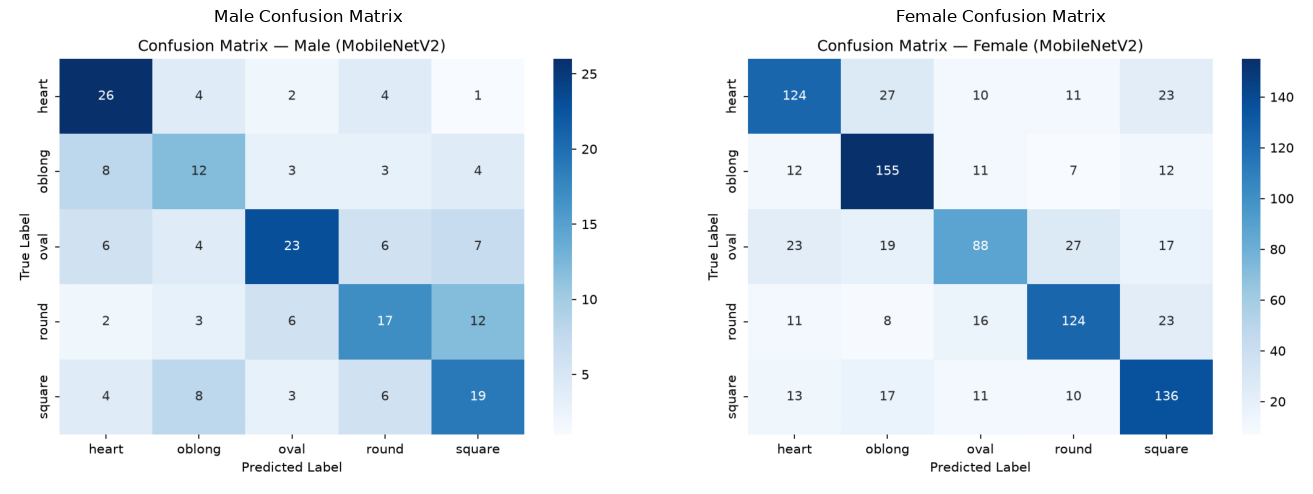

In [3]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, gender in zip(axes, ['male', 'female']):
    path = f'model/confusion_{gender}.png'
    if os.path.exists(path):
        ax.imshow(mpimg.imread(path))
        ax.axis('off')
        ax.set_title(f'{gender.capitalize()} Confusion Matrix')
    else:
        ax.text(0.5, 0.5, f'Run training first', ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{gender} — not found')
plt.tight_layout()
plt.show()

## Section 3 — MLOps Implementation
### 3.1 Version Control — GitHub
* Repository: https://github.com/Hamdha-Saheer/look-eyewear-recommendation.git
* **Usage**: Git is used for tracking changes across application code (`app.py`), MLflow experiment scripts, Flask templates, and GitHub Actions CI/CD workflow configurations.

### 3.2 DVC — Data Version Control (Conceptual Design)
DVC extends Git to track large files such as datasets and model weights.

**How DVC is designed for LOOK (Explained, not actively configured due to storage limits):**
* **Dataset Versioning**: Conceptual workflow to track `data_clean/` across raw vs. preprocessed states (e.g., preserving state before and after removing the 98 bad images).
* **Artifact Tracking**: Design pattern to manage heavy PyTorch model weights (`model_male.pth`, `model_female.pth`) via remote storage pointers (`.dvc` files).
* **Reproducibility & Rollbacks**: Proposed mechanism for rolling back model releases or data states if performance drops.

### 3.3 CI/CD — GitHub Actions
File: .github/workflows/test.yml

Pipeline runs on every git push:
1. Checkout code
2. Set up Python 3.11
3. Install dependencies
4. Test all imports work
5. Verify required files exist
6. Validate recommendations.json

![GitHub Actions CI/CD Pipeline](cicd_pipeline.png)

### 3.4 Docker Containerisation
To ensure consistent execution across different environments, the application is fully containerised. The `Dockerfile` is configured to package the Flask application, PyTorch models, and critical system dependencies (e.g., OpenCV libraries).

```
docker build -t look-app .
docker run -p 5000:5000 look-app
```


### 3.5 Flask Deployment
Running locally at http://127.0.0.1:5000

| Route | Method | Purpose |
|---|---|---|
| / | GET | Frontend HTML |
| /predict | POST | Detect face shape |
| /predict_shape | POST | Manual override |
| /tryon | POST | Virtual try-on |
| /monitor | GET | Prediction statistics |

### 3.6 Model Monitoring — Logging & Endpoint

![Flask Monitoring Endpoint Output](monitor_endpoint.png)

In [4]:
from collections import Counter

log_path = 'logs/predictions.log'

if os.path.exists(log_path):
    shapes = []
    genders = []
    low_conf = 0
    total = 0
    with open(log_path) as f:
        for line in f:
            if 'PREDICTION |' not in line:
                continue
            total += 1
            for part in line.split('|'):
                part = part.strip()
                if part.startswith('shape='):
                    shapes.append(part.split('=')[1])
                if part.startswith('gender='):
                    genders.append(part.split('=')[1])
                if 'low_conf=True' in part:
                    low_conf += 1
    print(f'Total predictions : {total}')
    print(f'By shape          : {dict(Counter(shapes))}')
    print(f'By gender         : {dict(Counter(genders))}')
    if total > 0:
        print(f'Low confidence    : {low_conf} ({low_conf/total*100:.1f}%)')
else:
    print('No log file found.')
    print('Start app.py, upload 3-4 photos, then run this cell.')

Total predictions : 6
By shape          : {'heart': 2, 'round': 2, 'square': 2}
By gender         : {'male': 2, 'female': 4}
Low confidence    : 6 (100.0%)


### 3.7 Model Drift Discussion

| Drift Type | Description | Detection Method |
|---|---|---|
| Data drift | User photos differ from training (lighting, angles, demographics) | Monitor input image statistics |
| Prediction drift | Distribution of predicted shapes shifts over time | Monitor /monitor endpoint |
| Concept drift | New eyewear styles emerge that model was not trained on | Monitor recommendation usage |

Retraining trigger conditions:
- Low confidence rate exceeds 40%
- New training data collected with more than 200 new images per class
- Model accuracy on held-out test set drops below 60% (Female model) or 35% (Male model)
---
## Section 4 — MLOps Workflow Summary

```
DATA     : raw photos -> clean_data.py -> data_clean/ -> DVC tracked
TRAINING : train_model_mlflow.py -> MLflow logs all params and metrics
VERSION  : git commit -> GitHub -> tagged releases per model version
CI/CD    : git push -> GitHub Actions -> auto test + Docker build
DEPLOY   : python app.py -> Flask REST API on port 5000
MONITOR  : every /predict -> logs/predictions.log -> /monitor endpoint
```
Technologies used:
- Deep Learning: PyTorch MobileNetV2
- Experiment Tracking: MLflow 3.14.0
- Version Control: Git and GitHub
- Data Versioning: DVC (explained, not implemented due to storage limits)
- CI/CD: GitHub Actions
- Containerisation: Docker (Dockerfile included)
- Deployment: Flask REST API
- Monitoring: Python logging and /monitor endpoint